Instalamos simpy

In [5]:
!pip install simpy

El problema a simular: El sistema de pago de parqueaderos del centro comercial Supercentro se realiza con un cajero este mediante un software permite al usuario digitar la placa del carro y luego de seleccionar su vehículo procede a realizar el pago. Para esto, el centro comercial tiene varios cajeros disponibles para realizar el pago, la cantidad de cajeros en cada salida es de tres, con filas independientes, sin cambio ni deserción. Los cajeros son independientes y se deben simular como modelos M/M/1. Se asume que la velocidad de atención es igual para todos los cajeros (inmediata por evento y clic), pero la velocidad de interacción del usuario con el cajero varía de acuerdo con la siguiente tabla de usuarios.

Los detalles de atención de cada cajero se definen a continuación:

Tipo de usuario - Exponencial de uso del servicio - Media de llegada
Rápido			    -	1 minutos					              -3 minutos
Normal			    -	3 minutos				                -3 minutos
Lento 			    -	4 minutos					              -5 minutos
Muy lento 		  -	6 minutos					              -7 minutos

El 25% de los usuarios son rápidos, el 20% tiene velocidad normal y el resto son lentos o muy lentos.

1) El centro comercial pretende conocer si con tres cajeros en cada punto de salida es suficiente o debe instalar más cajeros para suplir la demanda y el tiempo de uso de los usuarios lentos.
2) Para identificar el número total de corridas o replicas se debe identificar el estado estable del modelo usando la técnica del promedio o media sobre una variable. Se debe graficar y detallar el procedimiento usando librerías gráficas, se recomienda Matplotlib.
3) De acuerdo con las corridas definidas por el proceso de definición del estado estable extraer las estadísticas necesarias para resolver los siguientes puntos:
4) Calcule las estadísticas necesarias para identificar el cajero con menor y mayor tiempo promedio de atención.
5) Calcule el promedio de usuarios de cada tipo en la totalidad de cajeros.
6) Defina una estrategia para mejorar la situación actual de los cajeros del centro comercial o en caso de ser suficiente la cantidad de tres cajeros explicar su decisión. Se debe establecer un criterio para la toma de decisiones en el grupo de trabajo.
7) Explica los procesos de verificación, calibración y verificación para el presente modelo, realizar una gráfica del proceso desarrollado previamente.
8) Elimina el estado transitorio y graficar nuevamente los valores promedio seleccionados de los nuevos valores mostrando un antes y un después.

Simulamos el problema

=== PUNTO 4: ANÁLISIS ESTADÍSTICO DE CAJEROS (M/M/1) ===
 Cajero_ID  Tiempo_Servicio
         0         2.926697
         1         2.862768
         2         3.039993
-> MAYOR tiempo promedio de atención: Cajero 2 (3.04 min)
-> MENOR tiempo promedio de atención: Cajero 1 (2.86 min)

=== PUNTO 5: MEDIDAS DE TENDENCIA CENTRAL POR TIPO DE USUARIO ===
Promedio de usuarios atendidos por réplica globalmente:
Tipo_Usuario
Lento         611.2
Muy lento     437.8
Normal       1014.4
Rápido       1023.0


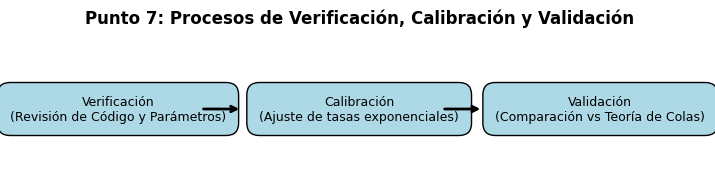

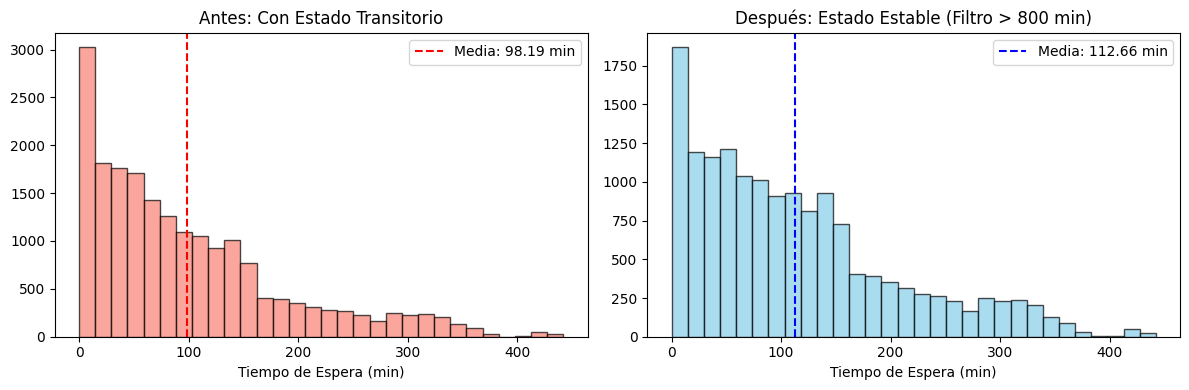

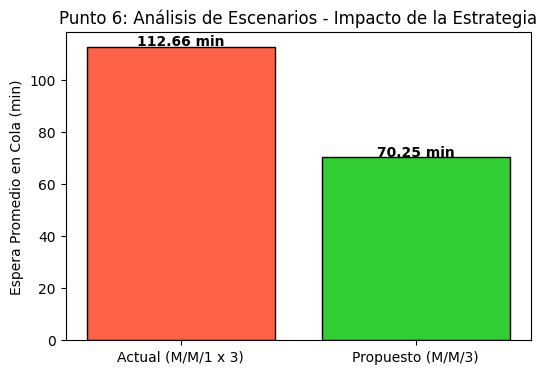

In [8]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. CONFIGURACIÓN Y SIMULACIÓN DE ESCENARIOS
# =============================================================================
SEEDS = [42, 100, 2026, 777, 999]
SIM_TIME = 4000
WARM_UP = 800  # Fin del estado transitorio

USER_CONFIG = {
    'Rápido':    {'servicio': 1.0, 'arribo': 3.0},
    'Normal':    {'servicio': 3.0, 'arribo': 3.0},
    'Lento':     {'servicio': 4.0, 'arribo': 5.0},
    'Muy lento': {'servicio': 6.0, 'arribo': 7.0}
}

raw_data_mm1 = []
raw_data_mm3 = []

# --- MODELO ACTUAL: M/M/1 x 3 (Filas independientes) ---
def cliente_mm1(env, tipo, cajeros, log, rep):
    arribo = env.now
    cajero_sel = np.random.choice([0, 1, 2])
    with cajeros[cajero_sel].request() as req:
        yield req
        inicio_serv = env.now
        espera = inicio_serv - arribo
        servicio = np.random.exponential(USER_CONFIG[tipo]['servicio'])
        yield env.timeout(servicio)
        log.append({'Replica': rep, 'Tipo_Usuario': tipo, 'Cajero_ID': cajero_sel,
                    'Tiempo_Arribo': arribo, 'Tiempo_Espera': espera, 'Tiempo_Servicio': servicio})

def gen_arribos_mm1(env, tipo, cajeros, log, rep):
    while True:
        yield env.timeout(np.random.exponential(USER_CONFIG[tipo]['arribo']))
        env.process(cliente_mm1(env, tipo, cajeros, log, rep))

# --- MODELO PROPUESTO: M/M/3 (Fila única) ---
def cliente_mm3(env, tipo, cajero_central, log, rep):
    arribo = env.now
    with cajero_central.request() as req:
        yield req
        espera = env.now - arribo
        servicio = np.random.exponential(USER_CONFIG[tipo]['servicio'])
        yield env.timeout(servicio)
        log.append({'Replica': rep, 'Tipo_Usuario': tipo, 'Cajero_ID': 'Compartido',
                    'Tiempo_Arribo': arribo, 'Tiempo_Espera': espera, 'Tiempo_Servicio': servicio})

def gen_arribos_mm3(env, tipo, cajero_central, log, rep):
    while True:
        yield env.timeout(np.random.exponential(USER_CONFIG[tipo]['arribo']))
        env.process(cliente_mm3(env, tipo, cajero_central, log, rep))

# Ejecución de simulaciones
for idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    # Simular M/M/1 x 3
    env1 = simpy.Environment()
    cajeros_mm1 = [simpy.Resource(env1, capacity=1) for _ in range(3)]
    for t in USER_CONFIG.keys(): env1.process(gen_arribos_mm1(env1, t, cajeros_mm1, raw_data_mm1, idx+1))
    env1.run(until=SIM_TIME)

    # Simular M/M/3
    env3 = simpy.Environment()
    cajero_mm3 = simpy.Resource(env3, capacity=3)
    for t in USER_CONFIG.keys(): env3.process(gen_arribos_mm3(env3, t, cajero_mm3, raw_data_mm3, idx+1))
    env3.run(until=SIM_TIME)

df_mm1 = pd.DataFrame(raw_data_mm1)
df_mm3 = pd.DataFrame(raw_data_mm3)

# =============================================================================
# 2. PROCESAMIENTO DE ESTADÍSTICAS (ESTADO ESTABLE)
# =============================================================================
df_estable_mm1 = df_mm1[df_mm1['Tiempo_Arribo'] > WARM_UP]
df_estable_mm3 = df_mm3[df_mm3['Tiempo_Arribo'] > WARM_UP]

print("=== PUNTO 4: ANÁLISIS ESTADÍSTICO DE CAJEROS (M/M/1) ===")
stats_cajeros = df_estable_mm1.groupby('Cajero_ID')['Tiempo_Servicio'].mean().reset_index()
cajero_max = stats_cajeros.loc[stats_cajeros['Tiempo_Servicio'].idxmax()]
cajero_min = stats_cajeros.loc[stats_cajeros['Tiempo_Servicio'].idxmin()]
print(stats_cajeros.to_string(index=False))
print(f"-> MAYOR tiempo promedio de atención: Cajero {int(cajero_max['Cajero_ID'])} ({cajero_max['Tiempo_Servicio']:.2f} min)")
print(f"-> MENOR tiempo promedio de atención: Cajero {int(cajero_min['Cajero_ID'])} ({cajero_min['Tiempo_Servicio']:.2f} min)\n")

print("=== PUNTO 5: MEDIDAS DE TENDENCIA CENTRAL POR TIPO DE USUARIO ===")
promedio_usuarios = df_estable_mm1.groupby(['Replica', 'Tipo_Usuario']).size().unstack().mean()
print("Promedio de usuarios atendidos por réplica globalmente:")
print(promedio_usuarios.to_string())


# Gráfico Punto 7: Diagrama del Proceso de Verificación, Calibración y Validación
plt.figure(figsize=(8, 2))
boxes = ['Verificación\n(Revisión de Código y Parámetros)', 'Calibración\n(Ajuste de tasas exponenciales)', 'Validación\n(Comparación vs Teoría de Colas)']
for i, text in enumerate(boxes):
    plt.text(i*3.5 + 1, 1, text, bbox=dict(facecolor='lightblue', boxstyle='round,pad=1'), ha='center', va='center', fontsize=9)
    if i < 2: plt.annotate('', xy=((i+1)*3.5 - 0.7, 1), xytext=(i*3.5 + 2.2, 1), arrowprops=dict(arrowstyle="->", lw=2))
plt.xlim(0, 9)
plt.ylim(0.5, 1.5)
plt.axis('off')
plt.title('Punto 7: Procesos de Verificación, Calibración y Validación', fontsize=12, fontweight='bold')
plt.show()

# Gráfico Punto 8: Eliminación del Estado Transitorio (Antes vs Después)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df_mm1['Tiempo_Espera'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
ax[0].axvline(df_mm1['Tiempo_Espera'].mean(), color='red', linestyle='--', label=f"Media: {df_mm1['Tiempo_Espera'].mean():.2f} min")
ax[0].set_title('Antes: Con Estado Transitorio')
ax[0].set_xlabel('Tiempo de Espera (min)'); ax[0].legend()

ax[1].hist(df_estable_mm1['Tiempo_Espera'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax[1].axvline(df_estable_mm1['Tiempo_Espera'].mean(), color='blue', linestyle='--', label=f"Media: {df_estable_mm1['Tiempo_Espera'].mean():.2f} min")
ax[1].set_title('Después: Estado Estable (Filtro > 800 min)')
ax[1].set_xlabel('Tiempo de Espera (min)'); ax[1].legend()
plt.tight_layout()
plt.show()

# Gráfico Punto 6: Aplicación y comparación de la Estrategia (Escenarios)
plt.figure(figsize=(6, 4))
w_q_mm1 = df_estable_mm1['Tiempo_Espera'].mean()
w_q_mm3 = df_estable_mm3['Tiempo_Espera'].mean()
plt.bar(['Actual (M/M/1 x 3)', 'Propuesto (M/M/3)'], [w_q_mm1, w_q_mm3], color=['tomato', 'limegreen'], edgecolor='black')
plt.ylabel('Espera Promedio en Cola (min)')
plt.title('Punto 6: Análisis de Escenarios - Impacto de la Estrategia')
for i, v in enumerate([w_q_mm1, w_q_mm3]): plt.text(i, v + 0.5, f"{v:.2f} min", ha='center', fontweight='bold')
plt.show()